In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ML -> Support Vector Machine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler    
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix

In [150]:
df = pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Machine_learning_indetails/dataset/Cardiovascular_Disease.csv')

In [151]:
# convert age days into years
df['age'] = round(df['age'] / 365)

In [152]:
df_sample =(df['ap_hi'].between(90,200)) & (df['ap_lo'].between(40,90)) 

In [153]:
df = df[df_sample]

In [154]:
weight_data = (df['weight'] >= 40) & (df['weight'] <= 140)
df = df[weight_data]

In [155]:
height = df['height']>=120

In [156]:
df= df[height]

In [157]:
columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
for col in columns:
    print(col)
    print('-'*20)
    max_value = df[col].max()
    print(f'max : {max_value}')
    min_val = df[col].min()
    print(f'min: {min_val}')
    print('-'*20)

age
--------------------
max : 65.0
min: 30.0
--------------------
height
--------------------
max : 207
min: 120
--------------------
weight
--------------------
max : 140.0
min: 40.0
--------------------
ap_hi
--------------------
max : 200
min: 90
--------------------
ap_lo
--------------------
max : 90
min: 40
--------------------


In [158]:
# take sample from original data
df_sample = df.sample(n= 5000,random_state =42)

In [159]:
df_sample.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
63868,91184,64.0,2,167,60.0,120,80,1,1,0,0,1,1
54110,77182,56.0,1,151,105.0,120,80,1,2,0,0,0,1
65183,93047,43.0,1,151,45.0,110,70,1,1,0,0,1,0
49117,70119,58.0,2,181,90.0,110,90,1,1,0,0,1,0
64525,92107,61.0,1,156,52.0,130,80,2,2,0,0,1,1


In [160]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [161]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [162]:
X = df_sample[features]
Y = df_sample[target]

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [164]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [175]:
model = SVC(kernel='linear', C=1.0, gamma='scale')


In [166]:
model.fit(X_train_scale, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [167]:
y_pred = model.predict(X_test_scale)

In [168]:
y_pred

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,

In [169]:

cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)


In [170]:
print(cr)


              precision    recall  f1-score   support

           0       0.68      0.81      0.74       520
           1       0.74      0.59      0.65       480

    accuracy                           0.70      1000
   macro avg       0.71      0.70      0.70      1000
weighted avg       0.71      0.70      0.70      1000



In [171]:
print(cm)

[[421  99]
 [199 281]]


Text(0.5, 23.52222222222222, 'Predicted')

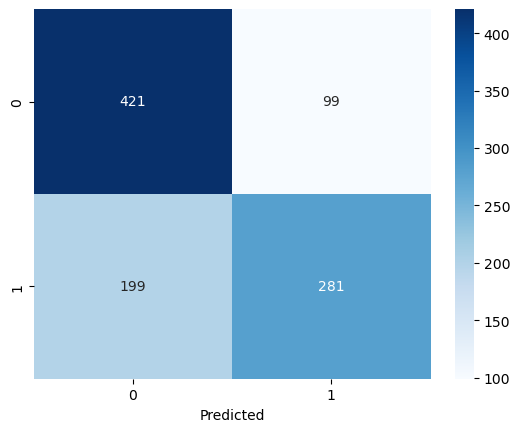

In [172]:
sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues')
plt.xlabel('Predicted')

In [173]:
# knn used for sam data